In [1]:
import pandas as pd

df = pd.read_csv('/content/PHL_dataset.csv')

print(df.head())
df.info()

                  P_NAME   P_DETECTION P_DISCOVERY_FACILITY  P_YEAR  \
0  OGLE-2016-BLG-1227L b  Microlensing                 OGLE    2020   
1           Kepler-276 c       Transit               Kepler    2013   
2           Kepler-829 b       Transit               Kepler    2016   
3               K2-283 b       Transit                   K2    2018   
4           Kepler-477 b       Transit               Kepler    2016   

     P_UPDATE  P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  P_MASS_LIMIT  \
0  2020-04-02  250.00            -120.0             413.0             0   
1  2018-09-25   16.60              -3.6               4.4             0   
2  2019-04-16    5.10               NaN               NaN             0   
3  2019-09-05   12.20               NaN               NaN             0   
4  2019-04-16    4.94               NaN               NaN             0   

      P_MASS_ORIGIN  ...  S_ABIO_ZONE  S_TIDAL_LOCK  P_HABZONE_OPT  \
0              Mass  ...          NaN      0.214133 

In [2]:
df.shape

(5599, 118)

In [3]:
cols_to_keep = [

    'P_HABITABLE',
    'P_ESI',
    'P_RADIUS',
    'P_MASS',
    'P_GRAVITY',
    'P_ESCAPE',
    'P_PERIOD',
    'P_SEMI_MAJOR_AXIS',
    'P_ECCENTRICITY',
    'P_INCLINATION',
    'P_TEMP_EQUIL',
    'P_TEMP_SURF',
    'P_TYPE_TEMP',

    'S_MASS',
    'S_RADIUS',
    'S_TEMPERATURE',
    'S_METALLICITY',
    'S_AGE',
    'S_MAG',
    'S_DISTANCE',
    'S_TYPE'
]


df = df[[col for col in cols_to_keep if col in df.columns]]

Identify missing values

In [4]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print('Columns with Missing Values :')
print(missing_df.head(30))

Columns with Missing Values :
                   Missing Values  Percentage
S_TYPE                       3578   63.904269
P_TEMP_SURF                  3158   56.402929
P_INCLINATION                1311   23.414896
S_AGE                        1207   21.557421
P_ECCENTRICITY                777   13.877478
S_METALLICITY                 433    7.733524
P_PERIOD                      249    4.447223
P_ESI                         241    4.304340
P_TYPE_TEMP                   234    4.179318
P_TEMP_EQUIL                  234    4.179318
S_RADIUS                      232    4.143597
S_MAG                         219    3.911413
S_TEMPERATURE                 219    3.911413
S_DISTANCE                     21    0.375067
P_RADIUS                        7    0.125022
P_MASS                          7    0.125022
P_GRAVITY                       7    0.125022
P_ESCAPE                        7    0.125022
P_SEMI_MAJOR_AXIS               4    0.071441
S_MASS                          4    0.071441


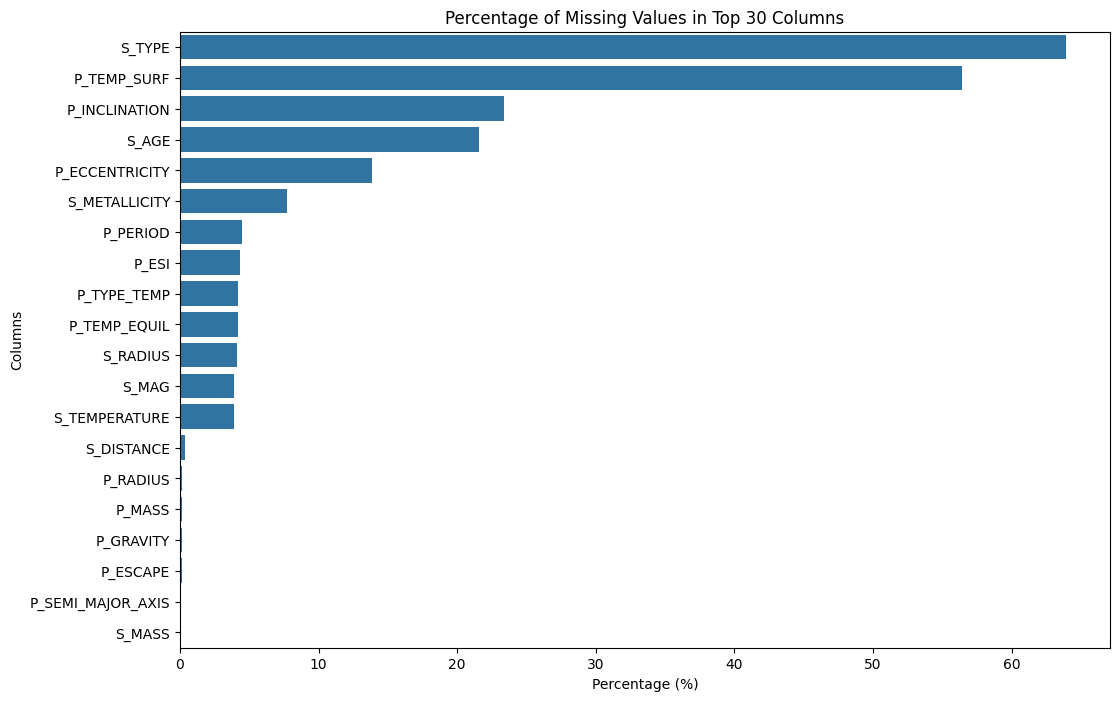

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df['Percentage'].head(30), y=missing_df.head(30).index)
plt.title('Percentage of Missing Values in Top 30 Columns')
plt.xlabel('Percentage (%)')
plt.ylabel('Columns')
plt.show()

In [6]:
numerical_cols = df.select_dtypes(include=['number']).columns

# Filter out numerical columns with more than 50% missing values
suitable_numerical_cols = [col for col in numerical_cols if missing_percentage.get(col, 0) <= 50]

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of suitable numerical columns (<= 50% missing values): {len(suitable_numerical_cols)}")
print("Suitable numerical columns for outlier detection:")
print(suitable_numerical_cols)

Number of numerical columns: 19
Number of suitable numerical columns (<= 50% missing values): 18
Suitable numerical columns for outlier detection:
['P_HABITABLE', 'P_ESI', 'P_RADIUS', 'P_MASS', 'P_GRAVITY', 'P_ESCAPE', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY', 'P_INCLINATION', 'P_TEMP_EQUIL', 'S_MASS', 'S_RADIUS', 'S_TEMPERATURE', 'S_METALLICITY', 'S_AGE', 'S_MAG', 'S_DISTANCE']


In [7]:
outliers_data = {}

for col in suitable_numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_data[col] = outliers

print("Outliers calculated for suitable numerical columns.")
print(f"Number of columns with identified outliers: {len([col for col, data in outliers_data.items() if not data.empty])}")

Outliers calculated for suitable numerical columns.
Number of columns with identified outliers: 18


In [8]:
for col, outliers in outliers_data.items():
    print(f"Column '{col}': {len(outliers)} outliers")

Column 'P_HABITABLE': 70 outliers
Column 'P_ESI': 291 outliers
Column 'P_RADIUS': 6 outliers
Column 'P_MASS': 957 outliers
Column 'P_GRAVITY': 1104 outliers
Column 'P_ESCAPE': 721 outliers
Column 'P_PERIOD': 940 outliers
Column 'P_SEMI_MAJOR_AXIS': 994 outliers
Column 'P_ECCENTRICITY': 579 outliers
Column 'P_INCLINATION': 439 outliers
Column 'P_TEMP_EQUIL': 86 outliers
Column 'S_MASS': 434 outliers
Column 'S_RADIUS': 364 outliers
Column 'S_TEMPERATURE': 267 outliers
Column 'S_METALLICITY': 201 outliers
Column 'S_AGE': 308 outliers
Column 'S_MAG': 62 outliers
Column 'S_DISTANCE': 260 outliers


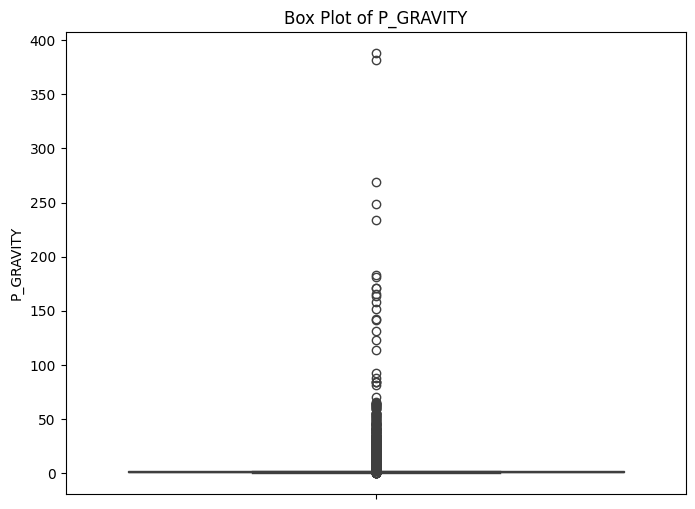

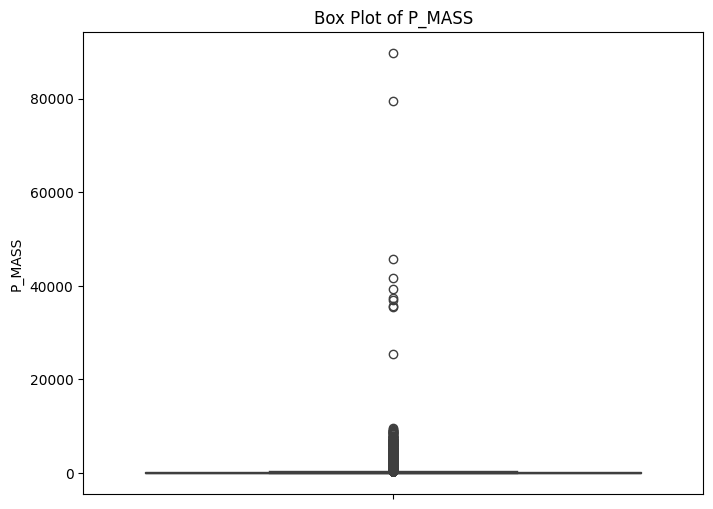

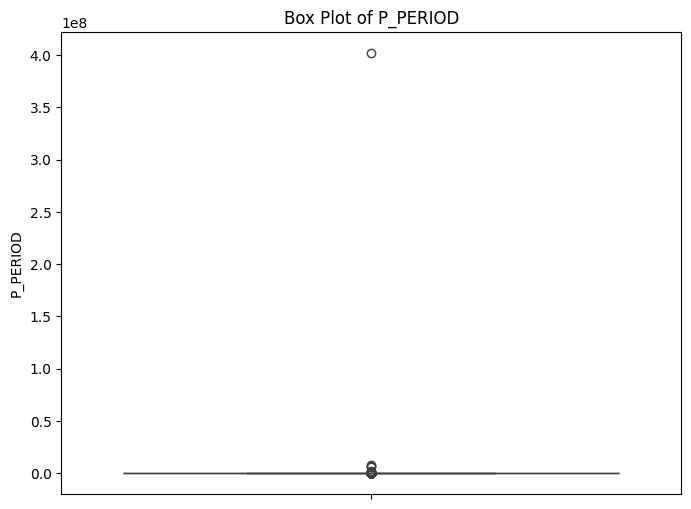

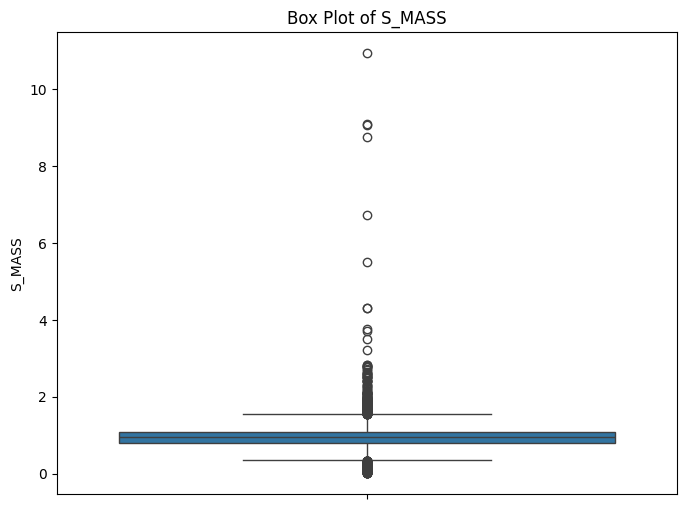

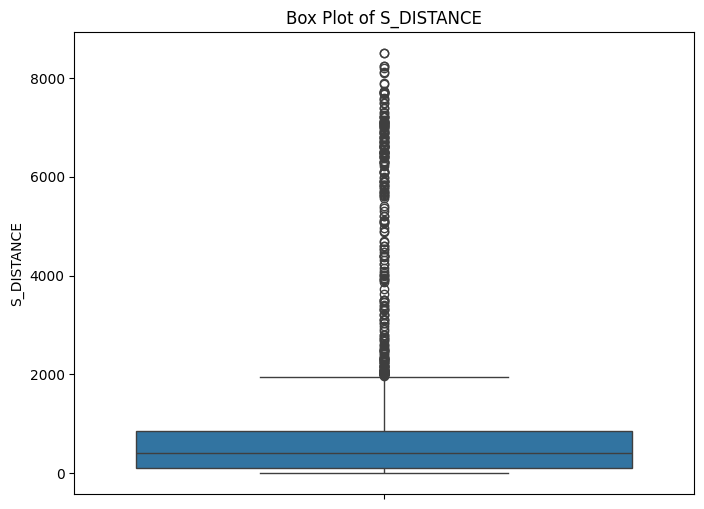

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS',  'S_DISTANCE']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


In [10]:
import pandas as pd

# Apply one-hot encoding to 'P_TYPE_TEMP as it has 3 unique values'
df = pd.get_dummies(df, columns=['P_TYPE_TEMP'], prefix='P_TYPE_TEMP')

print("DataFrame after one-hot encoding 'P_TYPE_TEMP':")
display(df.head())
df.info()

DataFrame after one-hot encoding 'P_TYPE_TEMP':


,P_HABITABLE,P_ESI,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_INCLINATION,...,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE,S_TYPE,P_TYPE_TEMP_Cold,P_TYPE_TEMP_Hot,P_TYPE_TEMP_Warm
0,0,NaN,13.90,250.00,1.293929,4.240945,NaN,3.4000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,0,0.272032,2.90,16.60,1.973841,2.392517,31.884000,0.1994,0.0,86.92,...,1.03,5779.0,0.02,0.40,15.481,1144.860,NaN,False,True,False
2,0,0.254763,2.11,5.10,1.145527,1.554690,6.883376,0.0678,0.0,89.82,...,0.97,5698.0,0.03,4.68,14.973,1073.760,NaN,False,True,False
3,0,0.193906,3.52,12.20,0.984633,1.861695,1.921036,0.0291,NaN,NaN,...,0.82,5060.0,0.28,NaN,14.364,402.915,NaN,False,True,False
4,0,0.276721,2.07,4.94,1.152886,1.544822,11.119907,0.0911,0.0,87.75,...,0.79,5240.0,-0.04,2.09,13.835,367.000,NaN,False,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   P_HABITABLE        5599 non-null   int64  
 1   P_ESI              5358 non-null   float64
 2   P_RADIUS           5592 non-null   float64
 3   P_MASS             5592 non-null   float64
 4   P_GRAVITY          5592 non-null   float64
 5   P_ESCAPE           5592 non-null   float64
 6   P_PERIOD           5350 non-null   float64
 7   P_SEMI_MAJOR_AXIS  5595 non-null   float64
 8   P_ECCENTRICITY     4822 non-null   float64
 9   P_INCLINATION      4288 non-null   float64
 10  P_TEMP_EQUIL       5365 non-null   float64
 11  P_TEMP_SURF        2441 non-null   float64
 12  S_MASS             5595 non-null   float64
 13  S_RADIUS           5367 non-null   float64
 14  S_TEMPERATURE      5380 non-null   float64
 15  S_METALLICITY      5166 non-null   float64
 16  S_AGE              4392 